In [124]:
import matplotlib.pyplot as plt
import numpy as np

In [125]:
plt.style.use("dark_background")
plt.rcParams["figure.figsize"] = (10, 8)

In [126]:
def get_linear_curve(x, w: float, b: float = 0, noise_scale: float = 0):
    return w * x + b + noise_scale * np.random.randn(x.shape[0])

In [127]:
x = np.arange(-10, 30.1, 0.5)
y = get_linear_curve(x, 1.8, 32, noise_scale=2.5)

In [128]:
x.shape, y.shape

((81,), (81,))

Text(0, 0.5, '°C')

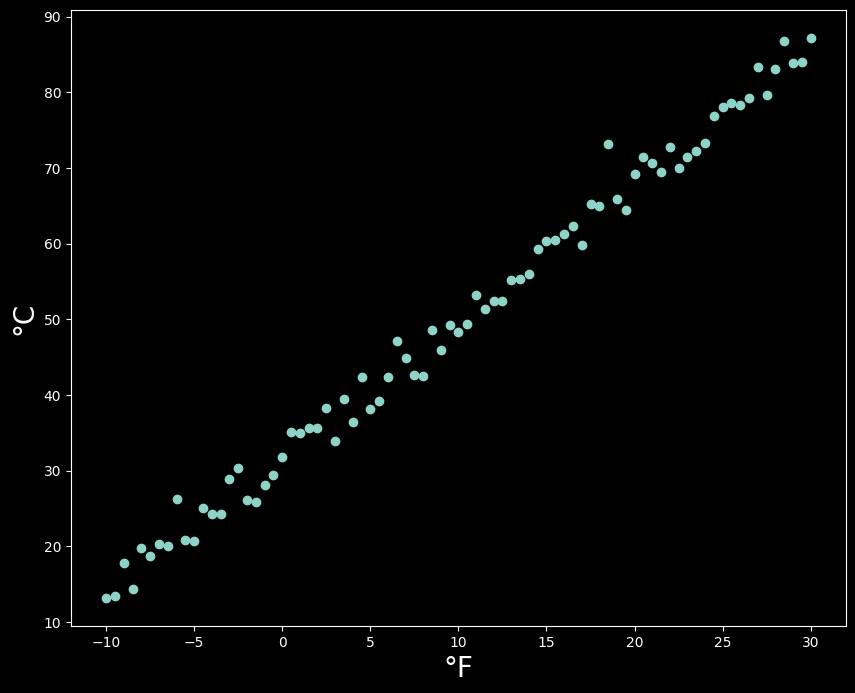

In [129]:
plt.scatter(x, y)
plt.xlabel('°F', fontsize=20)
plt.ylabel('°C', fontsize=20)

(array([3.000000e+00, 9.000000e+00, 5.500000e+01, 2.800000e+02,
        1.139000e+03, 4.030000e+03, 1.314300e+04, 3.709600e+04,
        9.118400e+04, 1.992220e+05, 3.801620e+05, 6.395960e+05,
        9.451850e+05, 1.228209e+06, 1.403821e+06, 1.409994e+06,
        1.245909e+06, 9.701540e+05, 6.624080e+05, 3.974250e+05,
        2.115150e+05, 9.858700e+04, 3.997600e+04, 1.464200e+04,
        4.613000e+03, 1.235000e+03, 3.140000e+02, 7.700000e+01,
        1.400000e+01, 3.000000e+00]),
 array([-5.4201955 , -5.05988543, -4.69957536, -4.33926529, -3.97895521,
        -3.61864514, -3.25833507, -2.898025  , -2.53771493, -2.17740485,
        -1.81709478, -1.45678471, -1.09647464, -0.73616457, -0.3758545 ,
        -0.01554442,  0.34476565,  0.70507572,  1.06538579,  1.42569586,
         1.78600594,  2.14631601,  2.50662608,  2.86693615,  3.22724622,
         3.5875563 ,  3.94786637,  4.30817644,  4.66848651,  5.02879658,
         5.38910665]),
 <BarContainer object of 30 artists>)

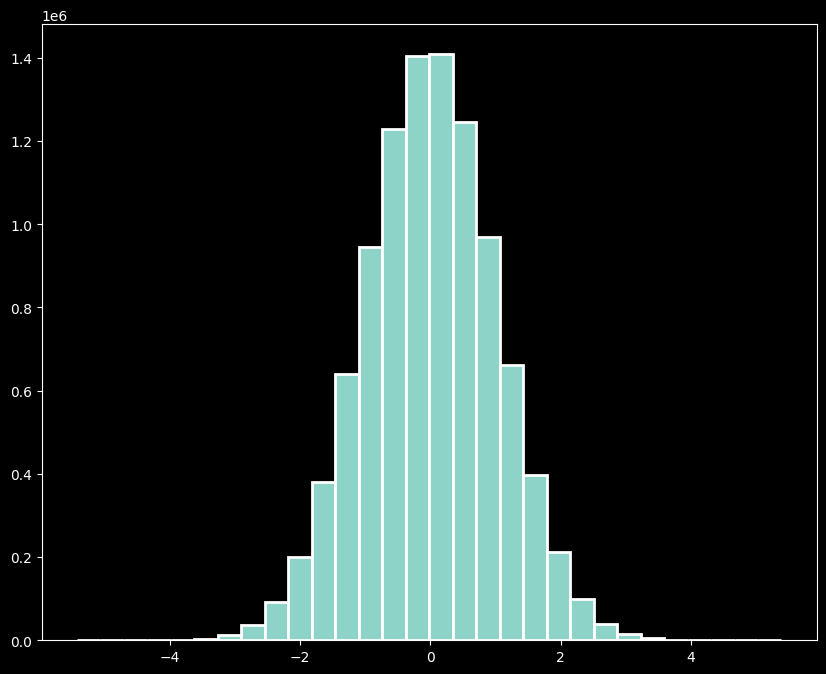

In [130]:
plt.hist(np.random.randn(10000000), bins=30, edgecolor="white", linewidth=2)

# Modelo
- Inicializar os pesos em bias
- Feedforward
- Calular a perda
- Backpropagation


In [131]:
# inicializar

peso = np.random.rand(1)
b = 0

In [132]:
def forward(inputs, w, b):
    return w * inputs + b

In [133]:
def mse(valor_real: np.ndarray, previsao: np.ndarray):
    return (valor_real - previsao) ** 2

In [134]:
def backpropagation(inputs: np.ndarray, outputs: np.ndarray, targets: np.ndarray, learning_rate: float, w, b):
    novo_peso = learning_rate * (-2 * inputs * (targets - outputs)).mean()
    novo_b = learning_rate * (-2 * (targets - outputs)).mean()

    w -= novo_peso
    b -= novo_b
    return w, b

In [135]:
def model_fit(inputs, target, w, b, epochs=200, learning_rate=0.001):
    for epoch in range(epochs):
        output = forward(inputs, w, b)
        loss = np.mean(mse(output, target))
        w, b = backpropagation(inputs, output, target, learning_rate, w, b)

        if (epoch + 1) % 50 == 0:
            print(f'epoch: [{(epoch + 1)} / {epochs}] loss: {loss:.4f}')
    return w, b

In [202]:
# inicialização
x = np.arange(-10, 10, 2)
y = get_linear_curve(x, w=1.8, b=32, noise_scale=2.5)

w = np.random.randn(1)
b = np.zeros(1)

# Treinando modelo
w, b = model_fit(x, y, w, b, epochs=500, learning_rate=0.029)
print(f'w: {w[0]:.3f}, b: {b[0]:.3f}')

epoch: [50 / 500] loss: 8.4772
epoch: [100 / 500] loss: 3.3997
epoch: [150 / 500] loss: 3.2558
epoch: [200 / 500] loss: 3.2464
epoch: [250 / 500] loss: 3.2457
epoch: [300 / 500] loss: 3.2457
epoch: [350 / 500] loss: 3.2457
epoch: [400 / 500] loss: 3.2457
epoch: [450 / 500] loss: 3.2457
epoch: [500 / 500] loss: 3.2457
w: 1.622, b: 30.791


In [203]:
aplt.scatter(x, y)
plt.plot(x, get_linear_curve(x, w, b), 'r', lw=3)

NameError: name 'aplt' is not defined